# Challenge 02 — Fase 1: Auditoría de Calidad, Limpieza y Decisiones de Imputación

**Curso:** Fundamentos en Ciencia de Datos (Maestría) — EAFIT · 2026-1
**Cliente:** TechLogistics S.A.S. (ficticio)

Esta libreta cubre el ciclo completo de la Fase 1 del reto:

1. **Diagnóstico** — perfilamiento de los 3 datasets crudos y detección de problemas (GIGO).
2. **Limpieza aplicada** — se ejecuta `src/cleaning.py`, el módulo real que usará el dashboard.
3. **Decisiones de imputación explicadas** — para cada problema, qué se decidió y por qué.
4. **Verificación antes/después** — Health Score y tablas comparativas.

> La lógica de limpieza vive en `src/cleaning.py` (reutilizable por `app/app.py`).
> Esta libreta la **ejecuta y explica**, no la reimplementa.


## 0. Configuración e imports

In [2]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

BASE = ".."
RAW = os.path.join(BASE, "data", "raw")
RESULTS = os.path.join(BASE, "results")
FIGURES = os.path.join(RESULTS, "figuras")
SRC = os.path.join(BASE, "src")
os.makedirs(FIGURES, exist_ok=True)
sys.path.insert(0, SRC)

INV_PATH = os.path.join(RAW, "inventario_central_v2.csv")
TRX_PATH = os.path.join(RAW, "transacciones_logistica_v2.csv")
FB_PATH  = os.path.join(RAW, "feedback_clientes_v2.csv")
print("Listo. Archivos esperados en:", RAW)


Listo. Archivos esperados en: ..\data\raw


In [3]:
def cargar_csv(path, nombre):
    """Lee un CSV crudo probando encodings. NO transforma nada."""
    for enc in ("utf-8", "latin-1", "cp1252"):
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"[{nombre}] leído con encoding='{enc}' -> {df.shape[0]} filas x {df.shape[1]} cols")
            return df
        except (UnicodeDecodeError, FileNotFoundError) as e:
            if isinstance(e, FileNotFoundError):
                print(f"[{nombre}] ARCHIVO NO ENCONTRADO en {path}")
                return None
            continue
    return None

df_inv_raw = cargar_csv(INV_PATH, "inventario")
df_trx_raw = cargar_csv(TRX_PATH, "transacciones")
df_fb_raw  = cargar_csv(FB_PATH,  "feedback")


[inventario] leído con encoding='utf-8' -> 2500 filas x 8 cols
[transacciones] leído con encoding='utf-8' -> 10000 filas x 10 cols
[feedback] leído con encoding='utf-8' -> 4500 filas x 9 cols


## 1. Diagnóstico (EDA) — perfilamiento de los 3 datasets crudos

Antes de limpiar, medimos el daño. Esto genera la evidencia que justifica cada
decisión de la sección 3.


In [4]:
def perfilar(df, nombre):
    print("=" * 70)
    print(f"DATASET: {nombre}  ->  {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print("=" * 70)
    print("\n--- % de nulos por columna ---")
    print((df.isna().mean() * 100).round(2).sort_values(ascending=False).to_string())
    print(f"\n--- Duplicados exactos (fila completa): {df.duplicated().sum():,} ---")
    return df

_ = perfilar(df_inv_raw, "inventario_central_v2")
_ = perfilar(df_trx_raw, "transacciones_logistica_v2")
_ = perfilar(df_fb_raw,  "feedback_clientes_v2")


DATASET: inventario_central_v2  ->  2,500 filas x 8 columnas

--- % de nulos por columna ---
Lead_Time_Dias        16.12
Stock_Actual           4.00
Categoria              0.00
SKU_ID                 0.00
Costo_Unitario_USD     0.00
Punto_Reorden          0.00
Bodega_Origen          0.00
Ultima_Revision        0.00

--- Duplicados exactos (fila completa): 0 ---
DATASET: transacciones_logistica_v2  ->  10,000 filas x 10 columnas

--- % de nulos por columna ---
Estado_Envio           16.83
Costo_Envio             8.34
SKU_ID                  0.00
Transaccion_ID          0.00
Cantidad_Vendida        0.00
Fecha_Venta             0.00
Precio_Venta_Final      0.00
Tiempo_Entrega_Real     0.00
Ciudad_Destino          0.00
Canal_Venta             0.00

--- Duplicados exactos (fila completa): 0 ---
DATASET: feedback_clientes_v2  ->  4,500 filas x 9 columnas

--- % de nulos por columna ---
Recomienda_Marca          24.87
Comentario_Texto          14.60
Feedback_ID                0.00
Rating_Prod

### 1.1 Inventario — hallazgos específicos

In [5]:
# Stock negativo
neg = (pd.to_numeric(df_inv_raw["Stock_Actual"], errors="coerce") < 0).sum()
print(f"Stock_Actual negativo: {neg}")

# Costo unitario: rango
cu = pd.to_numeric(df_inv_raw["Costo_Unitario_USD"], errors="coerce")
print(f"Costo_Unitario_USD -> min: {cu.min()}, max: {cu.max()}")

# Lead_Time_Dias: composición real de los valores no numéricos
lt_num = pd.to_numeric(df_inv_raw["Lead_Time_Dias"], errors="coerce")
no_num = df_inv_raw["Lead_Time_Dias"].notna() & lt_num.isna()
print(f"\nLead_Time_Dias no numéricos: {no_num.sum()}")
print(df_inv_raw.loc[no_num, "Lead_Time_Dias"].value_counts().to_string())

# Categoria: cuántos valores únicos "de más" hay
print(f"\nCategoria -> {df_inv_raw['Categoria'].nunique()} valores únicos crudos:")
print(df_inv_raw["Categoria"].value_counts(dropna=False).to_string())


Stock_Actual negativo: 60
Costo_Unitario_USD -> min: 0.05, max: 850000.0

Lead_Time_Dias no numéricos: 887
Lead_Time_Dias
25-30 días    454
Inmediato     433

Categoria -> 8 valores únicos crudos:
Categoria
Laptops        329
Monitores      327
Smartphones    314
Tablets        309
Accesorios     307
smart-phone    306
???            305
LAPTOP         303


### 1.2 Transacciones — hallazgos específicos

In [6]:
q = pd.to_numeric(df_trx_raw["Cantidad_Vendida"], errors="coerce")
print(f"Cantidad_Vendida negativa: {(q < 0).sum()}")

te = pd.to_numeric(df_trx_raw["Tiempo_Entrega_Real"], errors="coerce")
print(f"Tiempo_Entrega_Real -> min: {te.min()}, max: {te.max()}, ==999: {(te==999).sum()}")

ce = pd.to_numeric(df_trx_raw["Costo_Envio"], errors="coerce")
print(f"Costo_Envio nulo: {ce.isna().sum()}")

print(f"\nEstado_Envio nulo: {df_trx_raw['Estado_Envio'].isna().sum()} "
      f"({100*df_trx_raw['Estado_Envio'].isna().mean():.1f}%)")

print("\nCiudad_Destino -> ¿contaminación cruzada con Canal_Venta?")
print(df_trx_raw["Ciudad_Destino"].value_counts(dropna=False).to_string())

# Integridad referencial: SKU fantasma
skus_inv = set(df_inv_raw["SKU_ID"].dropna().unique())
fantasma = ~df_trx_raw["SKU_ID"].isin(skus_inv)
print(f"\nVentas con SKU inexistente en inventario (SKU fantasma): "
      f"{fantasma.sum():,} ({100*fantasma.mean():.1f}%)")


Cantidad_Vendida negativa: 100
Tiempo_Entrega_Real -> min: 1, max: 999, ==999: 50
Costo_Envio nulo: 834

Estado_Envio nulo: 1683 (16.8%)

Ciudad_Destino -> ¿contaminación cruzada con Canal_Venta?
Ciudad_Destino
Ventas_Web      1290
BOG             1267
Bogotá          1261
Cali            1256
Bucaramanga     1250
Medellín        1234
MED             1223
Barranquilla    1219

Ventas con SKU inexistente en inventario (SKU fantasma): 1,751 (17.5%)


### 1.3 Feedback — hallazgos específicos

In [7]:
for col in ["Rating_Producto", "Rating_Logistica"]:
    r = pd.to_numeric(df_fb_raw[col], errors="coerce")
    print(f"{col} -> min: {r.min()}, max: {r.max()}, fuera de [1-5]: {((r<1)|(r>5)).sum()}")

e = pd.to_numeric(df_fb_raw["Edad_Cliente"], errors="coerce")
print(f"\nEdad_Cliente -> min: {e.min()}, max: {e.max()}, >100: {(e>100).sum()}")

nps = pd.to_numeric(df_fb_raw["Satisfaccion_NPS"], errors="coerce")
print(f"Satisfaccion_NPS -> min: {nps.min()}, max: {nps.max()}")

print(f"\nFeedback_ID -> {df_fb_raw['Feedback_ID'].nunique()} únicos de {len(df_fb_raw)} filas "
      f"({df_fb_raw['Feedback_ID'].duplicated(keep=False).sum()} filas en colisión de ID)")

# ¿Son copias exactas o colisiones con contenido distinto?
dup_ids = df_fb_raw[df_fb_raw["Feedback_ID"].duplicated(keep=False)]
ejemplo = dup_ids["Feedback_ID"].iloc[0]
print(f"\nEjemplo de colisión (Feedback_ID={ejemplo}):")
print(df_fb_raw[df_fb_raw["Feedback_ID"] == ejemplo])

print(f"\nRecomienda_Marca -> valores crudos: {df_fb_raw['Recomienda_Marca'].value_counts(dropna=False).to_dict()}")
print(f"Ticket_Soporte_Abierto -> valores crudos: {df_fb_raw['Ticket_Soporte_Abierto'].value_counts(dropna=False).to_dict()}")


Rating_Producto -> min: 1, max: 99, fuera de [1-5]: 30
Rating_Logistica -> min: 1, max: 5, fuera de [1-5]: 0

Edad_Cliente -> min: 18, max: 195, >100: 23
Satisfaccion_NPS -> min: -99.8, max: 99.9

Feedback_ID -> 4000 únicos de 4500 filas (969 filas en colisión de ID)

Ejemplo de colisión (Feedback_ID=FB-8021):
     Feedback_ID Transaccion_ID  Rating_Producto  Rating_Logistica Comentario_Texto Recomienda_Marca  \
21       FB-8021      TRX-14968                3                 4        Excelente            Maybe   
4403     FB-8021      TRX-16660                5                 1              NaN            Maybe   

     Ticket_Soporte_Abierto  Edad_Cliente  Satisfaccion_NPS  
21                        0            53              34.1  
4403                     No            75              47.0  

Recomienda_Marca -> valores crudos: {'SI': 1162, 'NO': 1142, nan: 1119, 'Maybe': 1077}
Ticket_Soporte_Abierto -> valores crudos: {'Sí': 1158, '1': 1140, '0': 1117, 'No': 1085}


## 2. Health Score — ANTES de limpiar

Indicador auditable (0-100) que combina completitud (1 − % nulos) y unicidad
(1 − % duplicados). Es la foto de partida; la comparamos con el "después" en
la sección 5.


In [8]:
def health_score(df, nombre):
    completitud = 1 - df.isna().mean().mean()
    unicidad = 1 - (df.duplicated().sum() / len(df)) if len(df) else 0
    score = round(100 * (completitud + unicidad) / 2, 1)
    return {"dataset": nombre, "filas": len(df), "health_score": score}

resumen_antes = pd.DataFrame([
    health_score(df_inv_raw, "inventario"),
    health_score(df_trx_raw, "transacciones"),
    health_score(df_fb_raw,  "feedback"),
])
resumen_antes

,dataset,filas,health_score
0,inventario,2500,98.7
1,transacciones,10000,98.7
2,feedback,4500,97.8


## 3. Limpieza aplicada — `src/cleaning.py`

Aquí se ejecuta el módulo real de limpieza (el mismo que usará `app/app.py`).
Para cada dataset, el pipeline imprime **qué se hizo y por qué** — esa
trazabilidad es el requisito del "Módulo de Transparencia" del dashboard.

### Regla general de imputación que seguimos en todo el proyecto

| Situación | Técnica elegida | Por qué |
|---|---|---|
| Outlier extremo pero registro válido (costos, tiempos de entrega) | Winsorizing IQR o mediana | No perder el registro completo por una sola celda mala |
| Valor imposible / código de error (edad 195, rating 99, stock negativo) | `NaN` + imputación con mediana | La mediana es robusta a la distorsión que causó el propio error |
| Texto con significado numérico real (`"Inmediato"`, `"25-30 días"`) | Parseo explícito, NO se trata como faltante | Es información real, no ausencia de información |
| Nulo técnico disfrazado (`"???"`, `"---"`, `"N/A"`) | `NaN` explícito, luego se decide imputar o no según la columna | Si no se explicita, `isna()` no lo detecta y queda escondido |
| Contaminación cruzada entre columnas (`Ventas_Web` en `Ciudad_Destino`) | `NaN` + columna flag, **sin imputar** | No hay forma confiable de inferir el dato correcto |
| Colisión de ID (mismo ID, contenido distinto) | Regenerar ID único, **conservar la fila** | Es un problema de identificador, no un registro basura |
| Decisión de negocio pendiente (SKU fantasma) | Columna flag booleana, **sin eliminar ni imputar** | La resolución depende de una decisión de negocio, no técnica, y se resuelve en `feature_engineering.py` / el informe |
| Opinión subjetiva del cliente (`Recomienda_Marca` nulo) | Se deja como `NaN` | No se puede inventar la opinión de un cliente que no respondió |


In [9]:
from cleaning import clean_all_datasets

raw_datasets = {
    "inventario": df_inv_raw,
    "transacciones": df_trx_raw,
    "feedback": df_fb_raw,
}

datasets_limpios, reportes = clean_all_datasets(raw_datasets)

df_inv = datasets_limpios["inventario"]
df_trx = datasets_limpios["transacciones"]
df_fb  = datasets_limpios["feedback"]

for rep in reportes:
    print(f"\n{'='*70}\n{rep['dataset'].upper()}\n{'='*70}")
    for c in rep["cambios"]:
        print(f"\n[{c['columna']}] {c['accion']}")
        print(f"   {c['detalle']}")
    print(f"\nTotal nulos antes: {sum(rep['nulos_antes'].values())} -> después: {sum(rep['nulos_despues'].values())}")



INVENTARIO

[Costo_Unitario_USD] Winsorizing IQR
   Costos extremos (ej. $850,000) limitados al bigote del rango intercuartílico. No se eliminan filas, se acota el valor para no perder el registro del SKU.

[Lead_Time_Dias] Parseo de texto a número
   433 valores 'Inmediato' -> 0 días (dato real, no faltante). 454 rangos tipo '25-30 días' -> promedio del rango (punto medio).

[Stock_Actual] Negativos -> NaN + imputación con mediana
   60 valores de stock negativo tratados como nulo técnico. Mediana imputada: 1020.0 (robusta frente a la dispersión entre categorías).

[Categoria] Normalización de categorías + '???' -> NaN
   8 valores únicos crudos reducidos a 5 categorías reales (fusiona 'LAPTOP'+'Laptops', 'smart-phone'+'Smartphones'). 305 registros con '???' convertidos explícitamente a NaN.

[Categoria] Imputación de nulos con moda por Bodega_Origen
   305 categorías nulas (ex-'???') imputadas con la categoría más frecuente de su misma bodega de origen.

Total nulos antes: 503 -> de

## 4. Decisiones de imputación — detalle por caso

Esta sección desarrolla en prosa las decisiones más importantes tomadas en
`cleaning.py`, para el documento de hallazgos.


### 4.1 Inventario

- **`Costo_Unitario_USD`** (rango $0.05 – $850,000): se aplicó **Winsorizing IQR**
  (capping, no eliminación). Decisión: un costo unitario absurdo no invalida el resto
  del registro del SKU (categoría, stock, bodega siguen siendo información válida),
  así que se prefiere acotar el valor extremo a eliminarlo.
- **`Lead_Time_Dias`** mezclaba tres formatos: números puros, rangos de texto
  (`"25-30 días"`) e `"Inmediato"`. **Decisión clave:** `"Inmediato"` NO es un dato
  faltante, es 0 días — tratarlo como nulo habría descartado 433 registros válidos
  de reposición inmediata. Los rangos se resolvieron con el **punto medio**
  (`27.5` para `"25-30 días"`), una decisión neutral entre el escenario optimista
  y el conservador.
- **`Stock_Actual`** negativo (60 registros, imposible físicamente): se trató como
  nulo técnico y se imputó con la **mediana** (no la media, por la alta dispersión
  entre categorías de producto — un mouse y un monitor no tienen la misma escala
  de inventario).
- **`Categoria`**: 8 valores crudos se redujeron a **5 categorías reales**
  (`LAPTOP`/`Laptops`, `smart-phone`/`Smartphones` eran la misma categoría con
  formato distinto). El valor `"???"` (305 registros, 12.2%) se identificó como
  **nulo técnico disfrazado** — no una categoría — y se imputó con la **moda por
  bodega de origen** (asumiendo que la mezcla de productos es similar dentro de
  una misma bodega).


### 4.2 Transacciones

- **`Cantidad_Vendida`** negativa (100 registros): se convirtió a valor absoluto,
  asumiendo error de captura de signo. **Limitación reconocida:** sin una columna
  de tipo de transacción, no se puede distinguir con certeza una devolución real
  de un error — por eso se agregó la columna `Cantidad_Corregida` (booleana) para
  que el equipo de negocio pueda auditar o excluir estos casos si lo considera
  necesario.
- **`Costo_Envio`** nulo (834, 8.3%): se imputó con la **mediana por ciudad
  destino**, no una mediana global — el costo de envío depende fuertemente de la
  distancia/zona, así que una mediana por ciudad es más precisa.
- **`Tiempo_Entrega_Real = 999`** (50 registros): es un **valor centinela**, no una
  entrega real de 999 días. Se trató como nulo y se imputó con la mediana
  (~15 días), luego se aplicó IQR para acotar otros outliers menos extremos.
- **`Ciudad_Destino` contaminada con `"Ventas_Web"`** (1,290 registros, 12.9%):
  este es el hallazgo más importante de calidad del dataset — es un valor de
  `Canal_Venta` que se filtró a la columna de ciudad. **Decisión: no se imputa**
  una ciudad de reemplazo (no hay forma confiable de inferirla); se marca como
  `NaN` + una columna flag `Ciudad_Invalida`, para que quede excluida de
  cualquier análisis geográfico pero visible para auditoría.
- **`Estado_Envio`** nulo (1,683, 16.8%): **no se imputó con una moda estadística**
  a propósito — inventar que un envío fue "Entregado" cuando no se sabe
  distorsionaría directamente el KPI de servicio al cliente (Pregunta 2 del
  reto). Se dejó como categoría explícita `"Desconocido"`, visible en el
  dashboard en vez de escondida.
- **SKU fantasma** (1,751 ventas, 17.5% del total): se agregó la columna
  `SKU_Fantasma` (booleana) sin eliminar ni imputar nada. Es el hallazgo central
  del reto (Pregunta 3) y su tratamiento final (¿producto nuevo no catalogado o
  error/fraude?) es una **decisión de negocio**, no una limpieza técnica — se
  resuelve con evidencia adicional en `feature_engineering.py` y se argumenta en
  el informe de hallazgos.


### 4.3 Feedback

- **`Feedback_ID` duplicado** (969 filas involucradas): al revisar el contenido,
  se confirmó que son **colisiones de identificador** (mismo ID, distinto
  `Transaccion_ID`/rating/edad), no copias exactas. **Decisión: no se eliminan**
  — se regenera un ID único agregando un sufijo, y se conserva el ID original en
  `Feedback_ID_Original` para trazabilidad. Se recuperaron así 500 registros de
  feedback real que una limpieza más ingenua habría descartado.
- **`Rating_Producto`/`Rating_Logistica` = 99**: es un código de error de
  captura, no un outlier real de la escala 1-5. Se trató como nulo y se imputó
  con la mediana (3.0).
- **`Edad_Cliente` > 100** (23 registros, hasta 195 años): imposibles
  biológicamente, se trataron como nulo y se imputaron con la mediana.
- **`Satisfaccion_NPS`** (rango -99.8 a 99.9): se verificó que coincide con la
  escala estándar de NPS (-100 a 100) — **no requiere renormalización**, solo se
  aseguró el tipo numérico.
- **`Recomienda_Marca`** nulo (24.9%): se dejó como `NaN` sin imputar — es la
  opinión subjetiva de un cliente que no respondió, no tiene sentido inventarla.
- **`Comentario_Texto`** con placeholders (`"N/A"`, `"---"`): se convirtieron a
  `NaN` explícito, sin imputar (texto libre, no se puede rellenar contenido).


## 5. Verificación — antes vs después

Comparamos el Health Score y algunas métricas clave para confirmar que la
limpieza mejoró la calidad medible de los datos.


In [10]:
resumen_despues = pd.DataFrame([
    health_score(df_inv, "inventario"),
    health_score(df_trx, "transacciones"),
    health_score(df_fb,  "feedback"),
])

comparativo = resumen_antes.merge(
    resumen_despues, on="dataset", suffixes=("_antes", "_despues")
)[["dataset", "health_score_antes", "health_score_despues"]]
comparativo["mejora_pts"] = (comparativo["health_score_despues"] - comparativo["health_score_antes"]).round(1)
comparativo

,dataset,health_score_antes,health_score_despues,mejora_pts
0,inventario,98.7,99.0,0.3
1,transacciones,98.7,99.5,0.8
2,feedback,97.8,97.3,-0.5


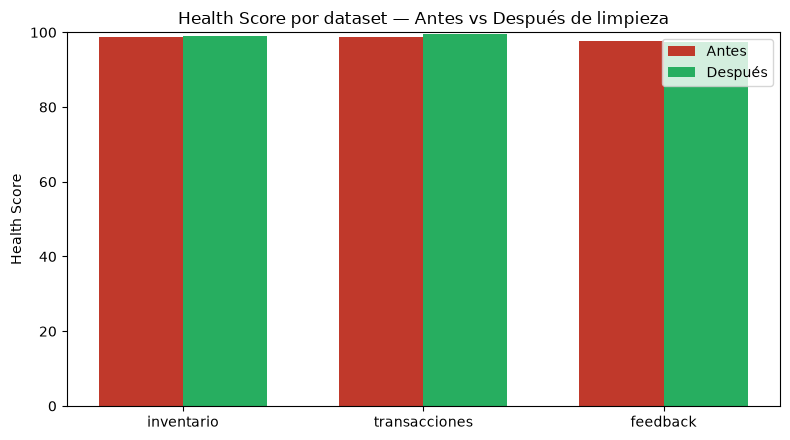

Figura guardada en results/figuras/health_score_antes_despues.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(comparativo))
width = 0.35
ax.bar(x - width/2, comparativo["health_score_antes"], width, label="Antes", color="#c0392b")
ax.bar(x + width/2, comparativo["health_score_despues"], width, label="Después", color="#27ae60")
ax.set_xticks(x)
ax.set_xticklabels(comparativo["dataset"])
ax.set_ylim(0, 100)
ax.set_ylabel("Health Score")
ax.set_title("Health Score por dataset — Antes vs Después de limpieza")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIGURES}/health_score_antes_despues.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura guardada en results/figuras/health_score_antes_despues.png")

### 5.1 Verificación puntual de cada fix

In [12]:
print("Categoria: de", df_inv_raw["Categoria"].nunique(), "valores crudos a", df_inv["Categoria"].nunique(), "categorías reales")
print(df_inv["Categoria"].value_counts().to_string())

print("\n¿'Ventas_Web' sigue en Ciudad_Destino?", (df_trx["Ciudad_Destino"] == "Ventas_Web").any())

print("\nFeedback: filas crudas =", len(df_fb_raw), "| filas limpias =", len(df_fb), "(no se debe perder ninguna)")

print("\nSKU_Fantasma flag:")
print(df_trx["SKU_Fantasma"].value_counts())


Categoria: de 8 valores crudos a 5 categorías reales
Categoria
Smartphones    780
Laptops        777
Monitores      327
Tablets        309
Accesorios     307

¿'Ventas_Web' sigue en Ciudad_Destino? False

Feedback: filas crudas = 4500 | filas limpias = 4500 (no se debe perder ninguna)

SKU_Fantasma flag:
SKU_Fantasma
False    8249
True     1751
Name: count, dtype: int64


## 6. Tabla de diagnóstico GIGO (actualizada con resultado tras limpieza)


In [13]:
diagnostico = []

def add(dataset, columna, problema, magnitud, accion_final, justificacion):
    diagnostico.append({
        "dataset": dataset, "columna": columna, "problema": problema,
        "magnitud": magnitud, "accion_final": accion_final, "justificacion": justificacion,
    })

add("inventario", "Costo_Unitario_USD", "Outliers extremos ($0.05-$850k)", "1 registro >=100k",
    "Winsorizing IQR", "No perder el resto del registro del SKU por un solo valor extremo")
add("inventario", "Lead_Time_Dias", "'Inmediato' + rangos de texto", "433 + 454",
    "'Inmediato'->0, rango->promedio", "'Inmediato' es dato real (0 días), no faltante")
add("inventario", "Stock_Actual", "Negativos", "60", "NaN + mediana",
    "Imposible físicamente; mediana robusta a dispersión entre categorías")
add("inventario", "Categoria", "8 valores para 5 categorías + '???'", "305 '???' + 3 variantes duplicadas",
    "Normalización + moda por bodega", "'???' es nulo técnico disfrazado, no categoría")
add("transacciones", "Cantidad_Vendida", "Negativos", "100", "Valor absoluto + flag",
    "Sin columna de tipo de transacción para distinguir devolución de error")
add("transacciones", "Costo_Envio", "Nulos", "834 (8.3%)", "Mediana por ciudad",
    "El costo de envío varía fuertemente por zona/distancia")
add("transacciones", "Tiempo_Entrega_Real", "Centinela 999", "50", "NaN + mediana + IQR",
    "999 no es una entrega real, es un código de error")
add("transacciones", "Ciudad_Destino", "Contaminación cruzada ('Ventas_Web')", "1,290 (12.9%)",
    "NaN + flag Ciudad_Invalida, SIN imputar", "No hay forma confiable de inferir la ciudad real")
add("transacciones", "Estado_Envio", "Nulos", "1,683 (16.8%)", "Categoría explícita 'Desconocido'",
    "Imputar un estado falso distorsionaría el KPI de servicio")
add("transacciones", "SKU_ID", "Venta fantasma (sin inventario)", "1,751 (17.5%)",
    "Flag SKU_Fantasma, SIN eliminar", "Decisión de negocio pendiente, no limpieza técnica")
add("feedback", "Feedback_ID", "Colisión de ID (no duplicado real)", "969 filas",
    "ID único regenerado, se conserva la fila", "Contenido distinto por fila; eliminar perdería feedback real")
add("feedback", "Rating_Producto/Logistica", "Código de error (99)", "30",
    "NaN + mediana", "99 no es un rating válido en escala 1-5")
add("feedback", "Edad_Cliente", "Edad imposible (>100)", "23", "NaN + mediana",
    "Imposible biológicamente")
add("feedback", "Recomienda_Marca", "Nulos + mayúsculas sin normalizar", "1,119 nulos (24.9%)",
    "Normalización case-insensitive; nulos SIN imputar", "Es opinión subjetiva; no se puede inventar")
add("feedback", "Comentario_Texto", "Placeholders ('N/A', '---')", "631",
    "NaN, sin imputar", "Texto libre, no se puede rellenar contenido")

tabla = pd.DataFrame(diagnostico)
out_path = f"{RESULTS}/tabla_diagnostico_gigo.csv"
tabla.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Tabla actualizada guardada en {out_path} ({len(tabla)} hallazgos)")
tabla

Tabla actualizada guardada en ..\results/tabla_diagnostico_gigo.csv (15 hallazgos)


,dataset,columna,problema,magnitud,accion_final,justificacion
0,inventario,Costo_Unitario_USD,Outliers extremos ($0.05-$850k),1 registro >=100k,Winsorizing IQR,No perder el resto del registro del SKU por un...
1,inventario,Lead_Time_Dias,'Inmediato' + rangos de texto,433 + 454,"'Inmediato'->0, rango->promedio","'Inmediato' es dato real (0 días), no faltante"
2,inventario,Stock_Actual,Negativos,60,NaN + mediana,Imposible físicamente; mediana robusta a dispe...
3,inventario,Categoria,8 valores para 5 categorías + '???',305 '???' + 3 variantes duplicadas,Normalización + moda por bodega,"'???' es nulo técnico disfrazado, no categoría"
4,transacciones,Cantidad_Vendida,Negativos,100,Valor absoluto + flag,Sin columna de tipo de transacción para distin...
5,transacciones,Costo_Envio,Nulos,834 (8.3%),Mediana por ciudad,El costo de envío varía fuertemente por zona/d...
6,transacciones,Tiempo_Entrega_Real,Centinela 999,50,NaN + mediana + IQR,"999 no es una entrega real, es un código de error"
7,transacciones,Ciudad_Destino,Contaminación cruzada ('Ventas_Web'),"1,290 (12.9%)","NaN + flag Ciudad_Invalida, SIN imputar",No hay forma confiable de inferir la ciudad real
8,transacciones,Estado_Envio,Nulos,"1,683 (16.8%)",Categoría explícita 'Desconocido',Imputar un estado falso distorsionaría el KPI ...
9,transacciones,SKU_ID,Venta fantasma (sin inventario),"1,751 (17.5%)","Flag SKU_Fantasma, SIN eliminar","Decisión de negocio pendiente, no limpieza téc..."


## 7. Datasets limpios listos para Feature Engineering

Los DataFrames `df_inv`, `df_trx`, `df_fb` de esta libreta son el resultado de
`clean_all_datasets()` — los mismos que usará `app/app.py`. Se exportan a
`data/processed/` para dejar registro del resultado de esta fase.


In [14]:
PROCESSED = os.path.join(BASE, "data", "processed")
os.makedirs(PROCESSED, exist_ok=True)

df_inv.to_csv(os.path.join(PROCESSED, "inventario_limpio.csv"), index=False)
df_trx.to_csv(os.path.join(PROCESSED, "transacciones_limpio.csv"), index=False)
df_fb.to_csv(os.path.join(PROCESSED, "feedback_limpio.csv"), index=False)
print("Datasets limpios exportados a data/processed/")


Datasets limpios exportados a data/processed/


## 8. Próximo paso

Con los datos limpios y trazados, el siguiente paso es **Fase 2: Integración y
Feature Engineering** (`src/feature_engineering.py`):

- Merge estratégico de los 3 datasets usando `SKU_ID` y `Transaccion_ID`.
- Resolver la decisión de negocio del **SKU fantasma** (columna `SKU_Fantasma`
  ya calculada aquí).
- Crear las variables derivadas: `Margen_Utilidad`, `Brecha_Entrega`,
  `Ratio_Soporte_Categoria`.

> Recuerda registrar en `docs/declaracion_uso_IA.md` qué partes de este análisis
> se apoyaron en IA generativa y cómo se validaron contra los datos reales.
